<a href="https://colab.research.google.com/github/rdityaza/Data-Analytics/blob/main/18223086_UTS_Data_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UTS II4013 Data Analytics
## Personalized Data Auditor & Decision Analyst

**Nama: Raditya Zaki Athaya**  
**NIM: 18223086**  
**Kelas: K02**  

### Pernyataan Keaslian
Saya menyatakan bahwa seluruh analisis pada notebook ini dikerjakan secara mandiri berdasarkan dataset yang dihasilkan dari NIM saya sendiri. Setiap keputusan analitik dijelaskan dengan alasan yang dapat saya pertanggungjawabkan.

## A. Tujuan Analisis

Jelaskan secara singkat:
1. Apa tujuan analisis Anda?
2. Apa target variabel yang akan dipelajari?
3. Keputusan apa yang ingin didukung oleh analisis ini?

**Tulis jawaban Anda di sini**
1. Memahami pola konsumsi energi di lingkungan Smart Campus dan mengidentifikasi faktor-faktor (seperti cuaca, jumlah mahasiswa, dan penggunaan perangkat) yang paling memengaruhi fluktuasi penggunaan energi tersebut.
2. Target variabel dalam analisis ini adalah energy_consumption.
3. Keputusan manajemen kampus dalam pengoptimalan alokasi daya listrik dan perencanaan jadwal penggunaan ruangan yang lebih efisien berdasarkan prediksi beban energi.

## B. Import Library
Jalankan sel berikut sebelum memulai analisis.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

plt.rcParams["figure.figsize"] = (8, 5)

## C. Membuat Dataset Personal

Tuliskan NIM Anda dan jalankan generator dataset.  
Pastikan dataset yang dianalisis berasal dari NIM Anda sendiri.

In [ ]:
# Isi dengan NIM masing-masing
nim = "18223086"

In [ ]:
def generate_dataset(nim, n_samples=500):
    np.random.seed(int(nim[-3:]))

    noise_level = int(nim[1])       # digit ke-2
    missing_pattern = int(nim[3])   # digit ke-4
    bias_factor = int(nim[-1])      # digit terakhir

    timestamp = pd.date_range(start="2024-01-01", periods=n_samples, freq="h")

    temperature = 25 + 5 * np.sin(np.linspace(0, 10, n_samples)) + np.random.randn(n_samples)
    humidity = 60 + 10 * np.cos(np.linspace(0, 5, n_samples)) + np.random.randn(n_samples)

    student_count = np.random.randint(50, 500, n_samples)
    device_usage = student_count * np.random.uniform(0.5, 1.5, n_samples)

    day_type = np.where(pd.Series(timestamp).dt.dayofweek < 5, "weekday", "weekend")

    energy = (
        0.5 * temperature +
        0.3 * humidity +
        0.01 * student_count +
        0.02 * device_usage +
        bias_factor * 2
    )

    # Komponen non-linear
    energy += 5 * np.sin(student_count / 100)

    # Noise berdasarkan NIM
    energy += np.random.randn(n_samples) * noise_level

    df = pd.DataFrame({
        "timestamp": timestamp,
        "temperature": temperature,
        "humidity": humidity,
        "student_count": student_count,
        "device_usage": device_usage,
        "day_type": day_type,
        "energy_consumption": energy
    })

    # Inject missing values berdasarkan pola NIM
    if missing_pattern % 3 == 0:
        df.loc[df.sample(frac=0.1, random_state=1).index, "temperature"] = np.nan
    elif missing_pattern % 3 == 1:
        df.loc[df.sample(frac=0.1, random_state=1).index, "humidity"] = np.nan
    else:
        df.loc[df.sample(frac=0.1, random_state=1).index, "student_count"] = np.nan

    # Inject outliers pada target
    outlier_idx = np.random.choice(df.index, size=int(0.05 * n_samples), replace=False)
    df.loc[outlier_idx, "energy_consumption"] *= (1 + bias_factor / 5)

    return df

In [ ]:
df = generate_dataset(nim)
df.head()

,timestamp,temperature,humidity,student_count,device_usage,day_type,energy_consumption
0,2024-01-01 00:00:00,24.403714,70.677596,115.0,125.175360,weekday,54.888567
1,2024-01-01 01:00:00,24.494775,69.211323,382.0,253.808390,weekday,53.921498
2,2024-01-01 02:00:00,25.657125,71.282486,50.0,70.788299,weekday,51.478784
3,2024-01-01 03:00:00,24.677200,70.793065,440.0,526.601214,weekday,48.149806
4,2024-01-01 04:00:00,26.093911,69.732314,NaN,446.627588,weekday,65.332741


In [ ]:
df.shape

(500, 7)

In [ ]:
# Simpan dataset personal agar mudah dilampirkan saat pengumpulan
output_csv = f"dataset_UTS_{nim}.csv"
df.to_csv(output_csv, index=False)
print(f"Dataset tersimpan sebagai: {output_csv}")

Dataset tersimpan sebagai: dataset_UTS_18223086.csv


## D. Data Understanding

Lakukan pemeriksaan awal terhadap dataset:
1. Ukuran data
2. Nama variabel
3. Tipe data
4. Ringkasan statistik
5. Dugaan awal masalah kualitas data

**Tulis interpretasi Anda setelah kode dijalankan.**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   timestamp           500 non-null    datetime64[ns]
 1   temperature         500 non-null    float64       
 2   humidity            500 non-null    float64       
 3   student_count       450 non-null    float64       
 4   device_usage        500 non-null    float64       
 5   day_type            500 non-null    object        
 6   energy_consumption  500 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 27.5+ KB


In [ ]:
df.describe(include="all")

,timestamp,temperature,humidity,student_count,device_usage,day_type,energy_consumption
count,500,500.000000,500.000000,450.000000,500.000000,500,500.000000
unique,NaN,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,NaN,NaN,NaN,weekday,NaN
freq,NaN,NaN,NaN,NaN,NaN,360,NaN
mean,2024-01-11 09:30:00,25.932192,58.096815,276.102222,280.369815,NaN,54.472551
min,2024-01-01 00:00:00,18.030086,48.139926,50.000000,39.085121,NaN,24.139248
25%,2024-01-06 04:45:00,22.978518,52.005222,162.750000,153.192259,NaN,45.717920
50%,2024-01-11 09:30:00,26.394144,56.793815,282.500000,256.827588,NaN,52.042250
75%,2024-01-16 14:15:00,28.913988,63.247735,381.000000,385.224962,NaN,58.361862
max,2024-01-21 19:00:00,32.616104,71.694701,499.000000,728.502943,NaN,164.738789


In [ ]:
df.isna().sum()

,0
timestamp,0
temperature,0
humidity,0
student_count,50
device_usage,0
day_type,0
energy_consumption,0


### Interpretasi Awal
Jawab pertanyaan berikut:
- Variabel mana yang numerik dan kategorikal?
- Apakah ada missing value?
- Apakah ada nilai yang tampak tidak wajar?
- Apakah target variabel tampak cocok untuk regresi?

**Tulis jawaban Anda di sini**
1. Numerik dan kategorikal
- Numerik : temperature, humidity, student_count, device_usage, dan target energy_consumption (semuanya bertipe float64).
- Kategorikal : timestamp sebagai variabel waktu (tipe datetime64) dan day_type bertipe object (kategorikal biner: weekend/weekday)

2. Terdapat missing value pada kolom student_count sebanyak 50 baris, yang berarti 10% dari data jumlah mahasiswa hilang.

3. Terdapat indikasi outlier ekstrem pada kolom target (energy_consumption). Jika dilihat dari statistik deskriptif, rata-rata nya berada di angka 54.472551 sehingga nilai minimum dan Q1-Q3 nya masih normal. Namun nilai max nya melonjak hingga 164.738789, ini menunjukkan adanya lonjakan konsumsi energi yang tidak wajar pada titik waktu tertentu.

4. Cocok untuk regresi karena bertipe numerik kontinu (float64) dengan rentang nilai yang bervariasi (dari 24.139248 hingga 164.738789) dan memiliki nilai standar deviasi 17.27, yang menunjukkan adanya fluktuasi yang bisa dipelajari oleh model.


## E. Audit Kualitas Data

Lakukan audit terhadap:
1. Missing values
2. Outliers
3. Ketidakkonsistenan format / tipe data
4. Potensi bias

In [ ]:
# Persentase missing value
missing_percent = df.isna().mean() * 100
missing_percent.sort_values(ascending=False)

,0
student_count,10.0
temperature,0.0
timestamp,0.0
humidity,0.0
device_usage,0.0
day_type,0.0
energy_consumption,0.0


In [ ]:
def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return mask.sum(), lower, upper, mask

outlier_summary = []
for col in ["temperature", "humidity", "student_count", "device_usage", "energy_consumption"]:
    count, lower, upper, mask = detect_outliers_iqr(df[col].dropna())
    outlier_summary.append({
        "column": col,
        "outlier_count": int(count),
        "lower_bound": float(lower),
        "upper_bound": float(upper)
    })

pd.DataFrame(outlier_summary)

,column,outlier_count,lower_bound,upper_bound
0,temperature,0,14.075314,37.817192
1,humidity,0,35.141453,80.111505
2,student_count,0,-164.625000,708.375000
3,device_usage,0,-194.856796,733.274017
4,energy_consumption,28,26.752007,77.327775


### Hasil Audit
Isi uraian singkat:
- Variabel bermasalah:
- Jenis masalah:
- Dampak potensial terhadap analisis:

**Tulis jawaban Anda di sini**
- Variabel bermasalah: energy_consumption (target) dan student_count (fitur).
- Jenis masalah: Terdapat 28 outliers pada target energy_consumption (nilai melampaui batas atas IQR yaitu 77.32). Selain itu, dari tahap sebelumnya diketahui ada 50 missing values pada student_count.
- Dampak potensial terhadap analisis: Outliers pada variabel target sangat berbahaya bagi Linear Regression karena model regresi sangat sensitif terhadap nilai ekstrem. Sementara missing values akan menyebabkan algoritma pemodelan gagal (error) saat dilatih jika tidak diimputasi.

## F. Penanganan Missing Value

Pilih satu metode imputasi yang menurut Anda paling tepat, misalnya:
- Mean
- Median
- Interpolation
- Metode lain

Jangan hanya menjalankan metode. Jelaskan:
1. Mengapa metode itu dipilih?
2. Mengapa metode lain tidak dipilih?

In [ ]:
df_clean = df.copy()

for col in ["temperature", "humidity", "student_count"]:
    if df_clean[col].isna().sum() > 0:
        df_clean[col] = df_clean[col].interpolate(method='linear', limit_direction='both') #sintaks ini dibantu oleh AI

print("Sisa missing value setelah reset & interpolasi:")
print(df_clean.isna().sum())

Sisa missing value setelah reset & interpolasi:
timestamp             0
temperature           0
humidity              0
student_count         0
device_usage          0
day_type              0
energy_consumption    0
dtype: int64


### Justifikasi Missing Value Handling
**Tulis jawaban Anda di sini**

1. Dataset ini direkam secara sekuensial per jam (time-series). Jumlah mahasiswa pada jam tertentu (misal 10:00) sangat berhubungan erat dengan jam sebelum (09:00) dan sesudahnya (11:00). Interpolasi linear mengisi kekosongan dengan menghubungkan titik sebelum dan sesudah data yang hilang, sehingga menjaga pola tren waktu tetap natural.

2. Menggunakan imputasi Mean atau Median secara global akan merusak pola temporal. Misalnya, nilai median jumlah mahasiswa adalah 282. Jika ada data kosong pada jam 02:00 pagi, metode Median akan mengisi angka 282 mahasiswa ke jam tersebut, yang mana tidak logis dan menyalahi perilaku kampus pada umumnya. Metode menghapus baris (Drop) juga tidak dipilih karena akan merusak urutan waktu (timestamp) dari data time-series ini.

## G. Outlier Handling dan Transformasi

Tentukan apakah outlier:
- Dipertahankan
- Dibatasi
- Dihapus
- Ditangani dengan model robust

Lalu tentukan apakah data perlu scaling atau transformasi.

In [ ]:
# Capping (Winsorization)
q1 = df_clean["energy_consumption"].quantile(0.25)
q3 = df_clean["energy_consumption"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# bandingkan efeknya sebelum dan sesudah
print(f"Batas atas (Upper Bound): {upper:.2f}")
print(f"Jumlah data di atas batas: {(df_clean['energy_consumption'] > upper).sum()}")

# Eksekusi Capping
df_clean["energy_capped"] = df_clean["energy_consumption"].clip(lower=lower, upper=upper)

# Menentukan target akhir untuk model
df_clean["target"] = df_clean["energy_capped"]

# Verifikasi hasil
print(f"Nilai max sebelum capping: {df_clean['energy_consumption'].max():.2f}")
print(f"Nilai max setelah capping: {df_clean['target'].max():.2f}")

Batas atas (Upper Bound): 77.33
Jumlah data di atas batas: 26
Nilai max sebelum capping: 164.74
Nilai max setelah capping: 77.33


### Justifikasi Outlier dan Transformasi
- Apakah outlier dihapus atau dipertahankan?
- Mengapa?
- Apa dampaknya terhadap model?

**Tulis jawaban Anda di sini**
1. Outlier dipertahankan namun dibatasi nilainya (Capping/Winsorization) pada batas atas IQR (77.33).

2. Saya membandingkan dua pendekatan: Menghapus data (Drop) dan Membatasi nilai (Capping). Saya memilih Capping karena:
- Ini adalah data time-series. Menghapus 28 baris outlier akan menyebabkan kekosongan pada urutan waktu dan menghilangkan informasi penting tentang aktivitas pada jam-jam tersebut.
- Nilai ekstrem sebesar 164.74 (padahal rata-rata hanya sekitar 54) kemungkinan besar adalah anomali noise atau kejadian luar biasa yang jika dibiarkan akan merusak garis regresi linear.

3. Dengan melakukan capping, model Linear Regression tidak akan ditarik terlalu jauh oleh nilai ekstrem tersebut. Hasilnya, model akan memiliki error (MSE/MAE) yang lebih rendah dan lebih akurat dalam memprediksi konsumsi energi pada kondisi normal harian.

## H. Visualisasi Data

Buat minimal:
1. Histogram target
2. Scatter plot fitur vs target
3. Visualisasi hubungan dua fitur

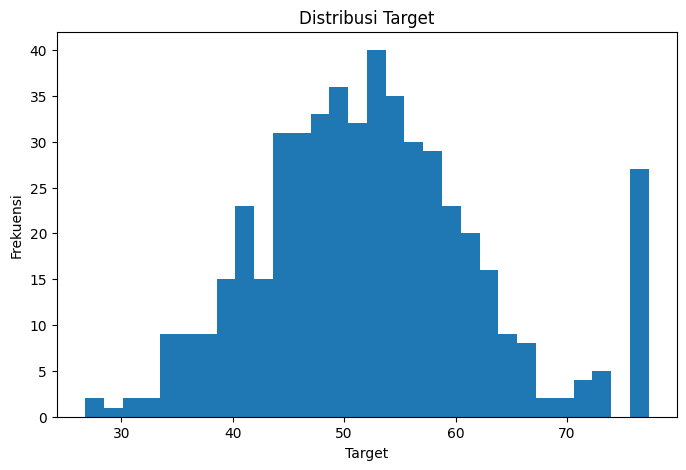

In [ ]:
plt.hist(df_clean["target"], bins=30)
plt.title("Distribusi Target")
plt.xlabel("Target")
plt.ylabel("Frekuensi")
plt.show()

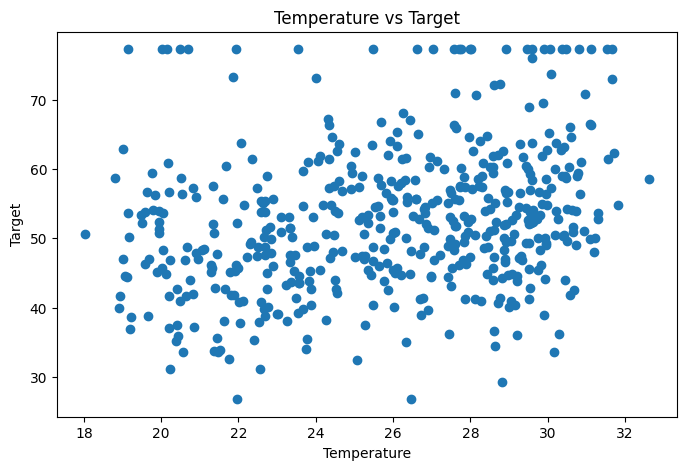

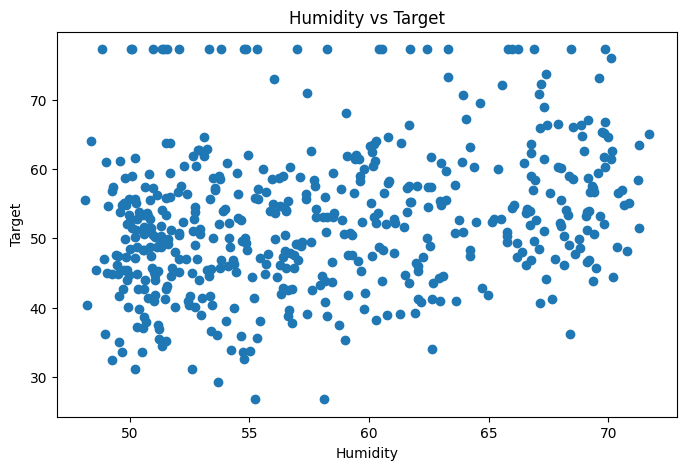

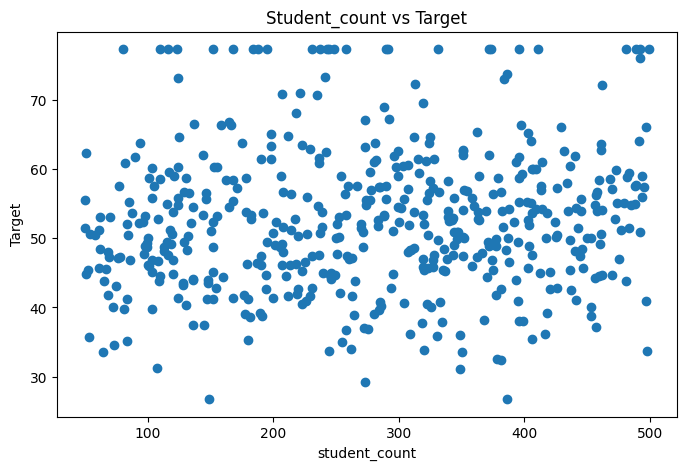

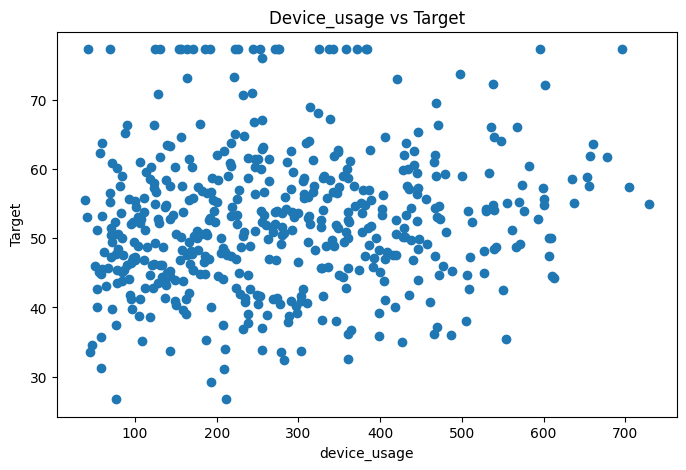

In [ ]:
# Temperature vs Target
plt.scatter(df_clean["temperature"], df_clean["target"])
plt.title("Temperature vs Target")
plt.xlabel("Temperature")
plt.ylabel("Target")
plt.show()

print("\n")
# Humidity vs Target
plt.scatter(df_clean["humidity"], df_clean["target"])
plt.title("Humidity vs Target")
plt.xlabel("Humidity")
plt.ylabel("Target")
plt.show()

print("\n")
# Student_count vs Target
plt.scatter(df_clean["student_count"], df_clean["target"])
plt.title("Student_count vs Target")
plt.xlabel("student_count")
plt.ylabel("Target")
plt.show()

print("\n")
# Device_usage vs Target
plt.scatter(df_clean["device_usage"], df_clean["target"])
plt.title("Device_usage vs Target")
plt.xlabel("device_usage")
plt.ylabel("Target")
plt.show()

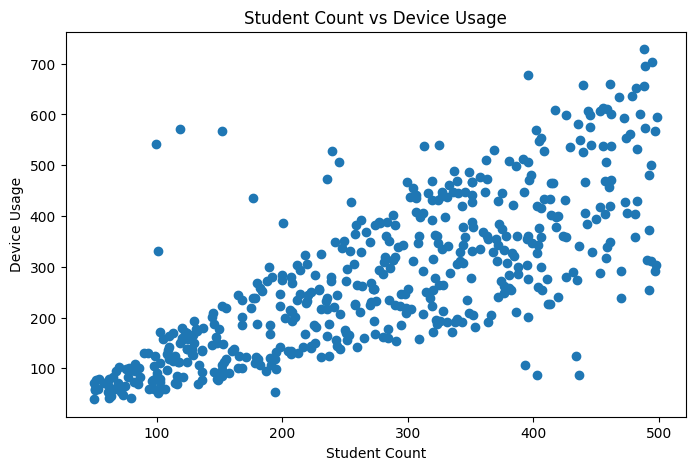

In [ ]:
plt.scatter(df_clean["student_count"], df_clean["device_usage"])
plt.title("Student Count vs Device Usage")
plt.xlabel("Student Count")
plt.ylabel("Device Usage")
plt.show()

### Interpretasi Visualisasi
Jawab:
- Apakah distribusi target simetris, skewed, atau memiliki ekor panjang?
- Fitur mana yang tampak memiliki hubungan kuat dengan target?
- Apakah ada pola non-linear?
- Apakah ada indikasi outlier atau cluster?

**Tulis jawaban Anda di sini**
1. Secara umum, bentuk bagian tengah grafik distribusi cukup simetris. Namun, terdapat penumpukan frekuensi pada bagian ujung kanan (sekitar nilai 77). Ini menunjukkan bukti visual dari efek capping sebelumnya yang mengumpulkan nilai-nilai ekstrem pada suatu batas maksimum.

2. Berdasarkan scatter plot semua fitur vs target yang divisualisasikan, secara keseluruhan hubungannya cukup lemah. Titik-titik data sangat tersebar luas sehingga sulit melihat korelasi pada fitur-fitur ini. Namun, fitur temperature merupakan fitur yang paling konsisten dibanding yang lain, diikuti oleh fitur humidity.

3. Pada grafik Student Count vs Device Usage, terdapat pola penyebaran melebar di bagian kanan, yang menunjukkan bahwa variansi penggunaan perangkat semakin membesar seiring bertambahnya mahasiswa.

4. Indikasi outliers sangat jelas pada semua grafik fitur vs target, ditunjukkan dengan adanya garis lurus horizontal berupa titik-titik yang berjejer rapat di batas paling atas grafik (sekitar nilai 77). Tidak ada indikasi cluster pada grafik grafik fitur vs target maupun Student Count vs Device Usage, data terpusat dan menyebar dalam satu distribusi yang kontinu.

## I. Encoding Variabel Kategorikal

Jika variabel kategorikal digunakan dalam model, lakukan encoding yang sesuai.

In [ ]:
df_model = df_clean.copy()
df_model = pd.get_dummies(df_model, columns=["day_type"], drop_first=True)
df_model.head()

,timestamp,temperature,humidity,student_count,device_usage,energy_consumption,energy_capped,target,day_type_weekend
0,2024-01-01 00:00:00,24.403714,70.677596,115.0,125.175360,54.888567,54.888567,54.888567,False
1,2024-01-01 01:00:00,24.494775,69.211323,382.0,253.808390,53.921498,53.921498,53.921498,False
2,2024-01-01 02:00:00,25.657125,71.282486,50.0,70.788299,51.478784,51.478784,51.478784,False
3,2024-01-01 03:00:00,24.677200,70.793065,440.0,526.601214,48.149806,48.149806,48.149806,False
4,2024-01-01 04:00:00,26.093911,69.732314,362.0,446.627588,65.332741,65.332741,65.332741,False


## J. Analisis Korelasi

Lakukan:
1. Korelasi Pearson antar variabel numerik
2. Interpretasikan hasilnya
3. Jelaskan keterbatasannya

In [ ]:
corr_cols = ["temperature", "humidity", "student_count", "device_usage", "target"]
corr_matrix = df_model[corr_cols].corr()
corr_matrix

,temperature,humidity,student_count,device_usage,target
temperature,1.000000,0.364388,0.073099,0.061675,0.273427
humidity,0.364388,1.000000,-0.059359,-0.083349,0.262264
student_count,0.073099,-0.059359,1.000000,0.756248,0.089625
device_usage,0.061675,-0.083349,0.756248,1.000000,0.132138
target,0.273427,0.262264,0.089625,0.132138,1.000000


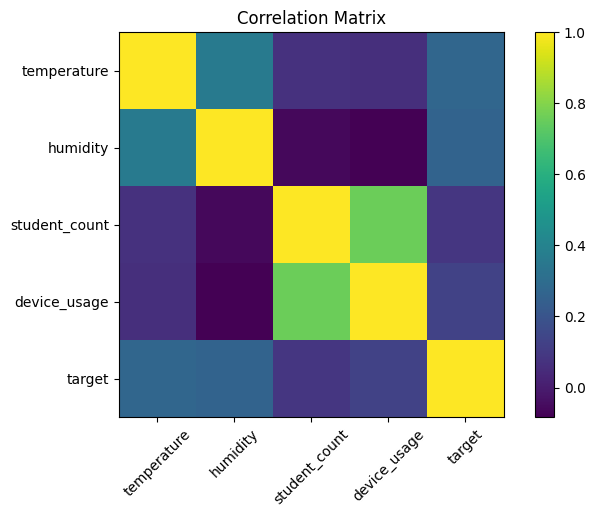

In [ ]:
plt.imshow(corr_matrix, interpolation="nearest")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

### Interpretasi Korelasi
Jawab:
- Fitur mana yang paling berkorelasi dengan target?
- Apakah korelasinya positif atau negatif?
- Apakah ada pasangan fitur yang saling berkorelasi tinggi?
- Apakah korelasi cukup untuk menyimpulkan sebab-akibat?

**Tulis jawaban Anda di sini**
1. Fitur temperature memiliki korelasi tertinggi terhadap target, disusul oleh humidity.

2. Semua fitur utama memiliki korelasi positif. Artinya, kenaikan suhu, kelembapan, maupun aktivitas mahasiswa cenderung meningkatkan konsumsi energi secara keseluruhan.

3. Ya, terdapat korelasi yang sangat kuat (warna hijau terang) antara student_count dan device_usage. Ini menunjukkan bahwa kedua variabel ini membawa informasi yang hampir sama (redundant).

4. Tidak. Korelasi hanya menunjukkan bahwa variabel-variabel tersebut bergerak searah secara statistik. Sebab-akibat membutuhkan analisis lebih dalam atau eksperimen, bukan sekadar melihat kesamaan pola data.

## K. Persiapan Data untuk Pemodelan Regresi

Pilih fitur input dan target.  
Jelaskan mengapa fitur tertentu digunakan atau tidak digunakan.

In [ ]:
feature_cols = ["temperature", "humidity", "student_count",  "day_type_weekend"]
X = df_model[feature_cols]
y = df_model["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)

Ukuran X_train: (400, 4)
Ukuran X_test : (100, 4)


### Justifikasi Pemilihan Fitur
**Tulis jawaban Anda di sini**
- Fitur yang digunakan: temperature, humidity, student_count, dan day_type_weekend. Variabel cuaca (suhu dan kelembapan) dipilih karena terbukti memiliki korelasi positif yang signifikan terhadap konsumsi energi. Status hari (weekend) dipertahankan untuk menangkap pola perbedaan aktivitas kampus di hari libur.

- Fitur yang tidak digunakan: device_usage. Variabel ini tidak digunakan karena hasil matriks korelasi sebelumnya menunjukkan adanya korelasi yang sangat ekstrem (mendekati 1.0) dengan student_count. Memasukkan kedua fitur ini sekaligus akan memicu masalah multikolinearitas, yang membuat koefisien regresi linear menjadi bias dan tidak stabil. Oleh karena itu, tingkat aktivitas cukup diwakili oleh variabel jumlah mahasiswa saja.

## L. Model 1 – Linear Regression

Bangun model baseline dengan regresi linear.

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin = lin_reg.predict(X_test)

In [ ]:
mae_lin = mean_absolute_error(y_test, y_pred_lin)
mse_lin = mean_squared_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print("Linear Regression Performance")
print("MAE :", mae_lin)
print("MSE :", mse_lin)
print("RMSE:", rmse_lin)
print("R2  :", r2_lin)

Linear Regression Performance
MAE : 7.394052512446445
MSE : 91.27696856370507
RMSE: 9.553898082128837
R2  : 0.10594931060997392


In [ ]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lin_reg.coef_
})
coef_df

,feature,coefficient
0,temperature,0.556913
1,humidity,0.291484
2,student_count,0.007667
3,day_type_weekend,-1.230358


### Interpretasi Model Linear
Jawab:
- Apa arti koefisien masing-masing fitur?
- Fitur mana yang paling dominan?
- Apakah tanda koefisien sesuai dugaan awal?
- Apakah performa model cukup baik?

**Tulis jawaban Anda di sini**
1. Setiap kenaikan 1 unit pada setiap fitur meningkatkan konsumsi energi sebesar nilai koefisien. Misalnya, kenaikan 1 unit temperatur berarti meningkatkan 0.55 unit konsumsi energi. Begitupun humidity dan student_count, masing-masing meningkatkan 0.29 dan 0.007 unit konsumsi energi. Variabel day_type_weekend memiliki koefisien -1.23, yang berarti konsumsi energi cenderung lebih rendah pada hari libur dibandingkan hari kerja.

2. temperature adalah fitur yang paling dominan dalam mendorong kenaikan energi, sementara day_type_weekend memberikan dampak pengurangan energi yang paling signifikan.

3. Tanda koefisien sesuai dengan logika awal, kenaikan suhu (memicu penggunaan AC) meningkatkan energi, dan hari libur (minim aktivitas di kampus) menurunkan energi.

4. Nilai $R^2$ yang rendah (~0.106) menunjukkan model hanya mampu menjelaskan sekitar 10,6% variasi data. Hal ini sangat wajar mengingat dataset memiliki tingkat noise yang sangat tinggi (skala 8), sehingga banyak fluktuasi energi yang tidak tertangkap oleh hubungan linear sederhana.

## M. Model 2 – Huber Regression

Bangun model robust untuk membandingkan sensitivitas terhadap outlier.

In [ ]:
huber = HuberRegressor()
huber.fit(X_train, y_train)

y_pred_huber = huber.predict(X_test)

In [ ]:
mae_huber = mean_absolute_error(y_test, y_pred_huber)
mse_huber = mean_squared_error(y_test, y_pred_huber)
rmse_huber = np.sqrt(mse_huber)
r2_huber = r2_score(y_test, y_pred_huber)

print("Huber Regression Performance")
print("MAE :", mae_huber)
print("MSE :", mse_huber)
print("RMSE:", rmse_huber)
print("R2  :", r2_huber)

Huber Regression Performance
MAE : 7.315556195441668
MSE : 90.89822209296304
RMSE: 9.534055909892864
R2  : 0.10965910234165943


### Perbandingan Model
Bandingkan Linear Regression dan Huber Regression:
- Model mana yang lebih baik?
- Mengapa?
- Apa kaitannya dengan keberadaan outlier?

**Tulis jawaban Anda di sini**
1. Huber Regression sedikit lebih baik dibandingkan Linear Regression, terlihat dari nilai MAE yang lebih rendah (7.31 vs 7.39) dan $R^2$ yang sedikit lebih tinggi (0.109 vs 0.105).

2. Huber Regression dirancang untuk menjadi model yang robust terhadap outlier. Algoritma ini tidak memberikan penalti kuadratis yang besar pada error ekstrem seperti pada Linear Regression konvensional.

3. Keunggulan Huber Regression dalam kasus ini membuktikan keberadaan 28 outliers yang terdeteksi di awal memang memengaruhi model. Huber berhasil memitigasi dampak titik-titik ekstrem tersebut sehingga menghasilkan prediksi yang lebih stabil untuk mayoritas data normal.

## N. Visualisasi Prediksi vs Aktual

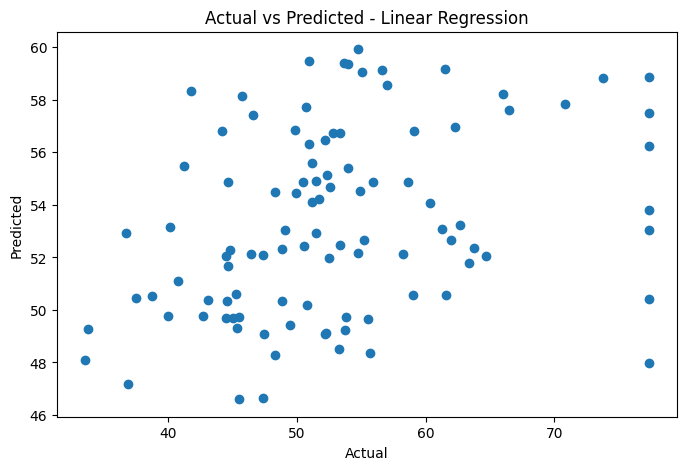

In [ ]:
plt.scatter(y_test, y_pred_lin)
plt.title("Actual vs Predicted - Linear Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

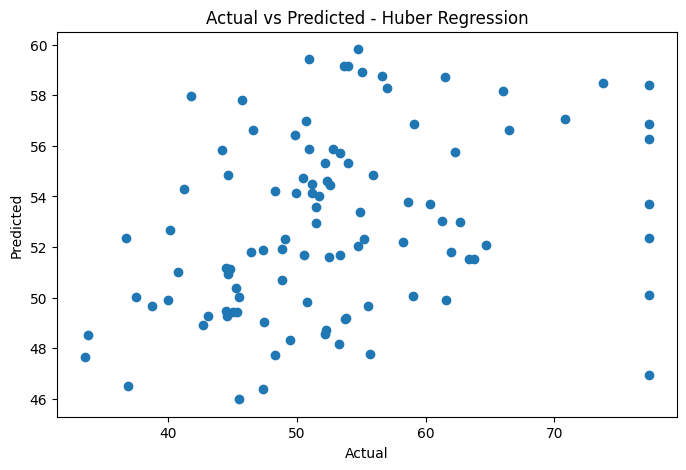

In [ ]:
plt.scatter(y_test, y_pred_huber)
plt.title("Actual vs Predicted - Huber Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

### Interpretasi Prediksi
- Apakah prediksi mengikuti nilai aktual?
- Di bagian mana model gagal?
- Apakah ada pola error tertentu?

**Tulis jawaban Anda di sini**
1. Hanya secara samar. Titik-titik prediksi menyebar luas dan tidak membentuk garis diagonal yang ideal (y = x). Model juga terlihat memprediksi dalam rentang yang lebih sempit (sekitar nilai 46 hingga 60 pada sumbu Y) dibandingkan dengan variasi nilai aktualnya yang jauh lebih lebar (rentang 30 hingga hampir 80 pada sumbu X).

2. Model paling banyak gagal dalam memprediksi nilai-nilai yang ekstrem, baik konsumsi energi yang sangat rendah (di bawah 40) maupun yang sangat tinggi (di atas 65). Model cenderung bermain aman dengan menebak di sekitar nilai rata-rata.

3. Ya, terdapat pola error yang sangat menonjol berupa garis titik-titik vertikal di sisi paling kanan grafik (pada sumbu X sekitar nilai 77). Ini adalah data outliers yang sebelumnya di-capping. Model secara konsisten menebak jauh lebih rendah untuk titik-titik data yang terkena capping tersebut.

## O. Analisis Kritis dan Refleksi

Jawab secara argumentatif:

1. Apa tiga temuan utama dari analisis Anda?
2. Apa risiko jika hasil model langsung dipakai untuk pengambilan keputusan?
3. Apakah hubungan yang ditemukan bersifat korelasional atau kausal?
4. Apa keterbatasan dataset Anda?
5. Jika diberi kesempatan memperbaiki analisis, apa yang akan Anda lakukan?

**Tulis jawaban Anda di sini**
1. Tiga temuan utama :
- Suhu (temperature) dan kelembapan (humidity) adalah pendorong utama kenaikan konsumsi energi secara statistik.
- Terdapat korelasi hampir sempurna antara jumlah mahasiswa (student_count) dan penggunaan perangkat (device_usage), sehingga salah satunya cukup mewakili tingkat aktivitas tanpa perlu memasukkan keduanya ke dalam model.
- Tingkat noise pada dataset ini sangat tinggi, menyebabkan model Linear Regression konvensional kesulitan memetakan hubungan yang presisi (tercermin dari nilai $R^2$ yang rendah, sekitar 10%).

2. Risikonya sangat tinggi jika dipakai untuk keputusan operasional yang butuh angka pasti (misalnya menetapkan budget listrik harian). Karena model hanya mampu menjelaskan $\approx 10\%$ variabilitas data, prediksi angka absolutnya rawan meleset jauh. Model ini lebih aman digunakan sebatas untuk melihat tren kasar (misal: "hari panas saat weekday dipastikan butuh energi ekstra"), bukan untuk presisi numerik.

3. Hubungan yang ditemukan murni bersifat korelasional. Analisis regresi dan matriks korelasi hanya membuktikan bahwa dua kejadian bergerak bersamaan. Misalnya, cuaca panas berkorelasi dengan energi tinggi, namun penyebab aslinya (kausal) kemungkinan besar adalah perilaku manusia yang menyalakan dan menurunkan suhu AC akibat cuaca tersebut.

4. Keterbatasan utamanya adalah tingginya tingkat fluktuasi acak (noise) bawaan pada data, adanya 10% data jumlah mahasiswa yang hilang (missing values), serta 28 outliers pada target energi. Selain itu, ada interaksi komponen non-linear tersembunyi yang membuat hubungan antar variabel tidak murni berupa garis lurus.

5. Saya akan beralih dari model parametrik sederhana (seperti Linear Regression) ke model algoritma machine learning non-linear yang lebih kompleks, seperti Random Forest atau XGBoost, karena algoritma tersebut lebih tangguh terhadap data yang sangat berisik dan bisa menangkap pola non-linear tanpa perlu banyak penyesuaian manual. Selain itu, saya akan mengekstrak fitur jam (hour) dari timestamp untuk menangkap pola perilaku jam sibuk di kampus.

## P. Log Keputusan Analitik

Isi tabel berikut:

| Tahap | Keputusan | Alasan |
|------|-----------|--------|
| Missing value | Menggunakan Interpolasi Linear pada kolom student_count. | Karena data bersifat time-series berurutan, interpolasi menjaga pola temporal harian agar tetap logis dengan menghubungkan titik sebelum dan sesudah kekosongan. |
| Outlier | Membatasi nilai ekstrem (Winsorization/Capping) pada target energy_consumption sesuai batas atas IQR. | Mencegah model linear tertarik secara ekstrem oleh outliers, tanpa harus menghapus baris data yang akan merusak urutan waktu observasi. |
| Transformasi | Melakukan One-Hot Encoding pada kolom day_type. | Mengubah tipe data teks/kategorikal menjadi biner (0/1) agar bisa diproses secara matematis oleh algoritma regresi. |
| Fitur model | Membuang device_usage dan menggunakan temperature, humidity, student_count, serta day_type_weekend. | Menghindari gejala multikolinearitas yang merusak model karena korelasi antara device_usage dan student_count hampir mencapai 1.0. |
| Model akhir | Membandingkan performa Linear Regression konvensional dengan Huber Regression. | Untuk membuktikan bahwa keberadaan sisa outliers / noise tinggi di data membuat model yang bersifat robust (seperti Huber) bekerja sedikit lebih baik dalam meminimalkan error. |

Lengkapi tabel dengan keputusan Anda sendiri.

## Q. Kesimpulan

Tuliskan kesimpulan akhir dalam 1–2 paragraf:
- Apa yang berhasil ditemukan?
- Model mana yang paling layak?
- Apakah hasil cukup kuat untuk mendukung keputusan?

**Tulis jawaban Anda di sini**

Berdasarkan analisis yang telah dilakukan, berhasil ditemukan bahwa variabel cuaca (suhu dan kelembapan) serta jumlah mahasiswa memiliki korelasi positif terhadap konsumsi energi di Smart Campus, sedangkan hari libur (weekend) menurunkannya secara signifikan. Selain itu, ditemukan juga bahwa variabel device_usage sangat identik dengan student_count, sehingga pembuangan salah satu fitur terbukti tepat untuk menghindari bias model. Di antara algoritma yang diuji, Huber Regression merupakan model yang paling layak dibandingkan Linear Regression. Hal ini dikarenakan algoritma Huber lebih tangguh (robust) dalam menangani anomali dan tingginya tingkat noise bawaan pada dataset ini, terbukti dari nilai evaluasi error (MAE dan RMSE) yang sedikit lebih rendah.

Meskipun demikian, hasil pemodelan ini belum cukup kuat untuk mendukung keputusan operasional yang bersifat presisi dan krusial. Nilai $R^2$ yang hanya berada di kisaran 10% menunjukkan bahwa model masih gagal menangkap $\approx 90\%$ variasi data yang sebagian besar berupa fluktuasi acak (noise) ekstrem. Jika manajemen kampus ingin menggunakan data ini untuk menetapkan alokasi anggaran energi yang pasti, disarankan untuk mengumpulkan data sensor yang lebih bersih (minim noise), menambah fitur waktu secara lebih mendetail, dan mengeksplorasi algoritma machine learning non-linear. Untuk saat ini, model hanya bisa dimanfaatkan sebagai pedoman tren secara makro, bukan kalkulator mutlak.

## Ketentuan Penting
1. Tidak cukup hanya menampilkan output kode.
2. Setiap tahap wajib disertai interpretasi.
3. Setiap keputusan preprocessing dan modeling wajib diberi alasan.
4. Jawaban generik tanpa keterkaitan dengan hasil aktual notebook akan dinilai rendah.
5. Fokus utama penilaian adalah kualitas penalaran, bukan sekadar angka performa.